In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Disable scientific notation, show plain numbers
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
# List of all 7 encoder result files we saved throughout the project
encoder_files = [
    "onehot_scores.csv",
    "ordinal_scores.csv",
    "frequency_scores.csv",
    "target_scores.csv",
    "catboost_scores.csv",
    "binary_scores.csv",
    "hashing_scores.csv"
]

# Load each file and combine them into a single long-format DataFrame.
# Since every notebook saved results in the same structure (encoder, model,
# fold, rmse, mae, r2), this is a simple concatenation, no reshaping needed.
all_results = pd.concat([pd.read_csv(f) for f in encoder_files], ignore_index=True)

# Sanity check: should be 7 encoders x 5 models x 5 folds = 175 rows
print(f"Total rows: {len(all_results)}")
print(f"Unique encoders: {all_results['encoder'].unique()}")
print(f"Unique models: {all_results['model'].unique()}")

all_results.head()

Total rows: 175
Unique encoders: <StringArray>
['onehot', 'ordinal', 'frequency', 'target', 'catboost', 'binary', 'hashing']
Length: 7, dtype: str
Unique models: <StringArray>
['Linear Regression', 'KNN', 'Decision Tree', 'Random Forest', 'Stacking']
Length: 5, dtype: str


,encoder,model,fold,rmse,mae,r2
0,onehot,Linear Regression,1,"2,585.88","1,484.80",0.97
1,onehot,Linear Regression,2,"2,539.79","1,492.31",0.97
2,onehot,Linear Regression,3,"2,393.26","1,447.58",0.97
3,onehot,Linear Regression,4,"2,314.39","1,449.21",0.97
4,onehot,Linear Regression,5,"2,714.55","1,500.86",0.96


In [3]:
# Pivot the data: rows = encoder, columns = model, values = mean RMSE across folds
# This gives us the core comparison table for the whole project
rmse_pivot = all_results.pivot_table(
    index="encoder",
    columns="model",
    values="rmse",
    aggfunc="mean"
)

rmse_pivot

model,Decision Tree,KNN,Linear Regression,Random Forest,Stacking
encoder,,,,,
binary,"3,147.93","2,884.07","4,926.01","2,150.52","2,152.43"
catboost,"2,789.95","2,353.54","4,216.37","1,983.80","1,977.49"
frequency,"3,058.04","2,668.41","5,086.37","2,151.80","2,163.33"
hashing,"3,488.41","3,418.60","5,123.64","2,464.13","2,485.63"
onehot,"2,861.75","3,829.70","2,509.57","2,092.59","2,071.61"
ordinal,"3,009.93","2,763.02","5,146.98","2,146.64","2,155.85"
target,"2,911.84","2,345.34","4,329.52","2,025.31","2,013.27"


In [4]:
# Same pivot, but for MAE
mae_pivot = all_results.pivot_table(
    index="encoder",
    columns="model",
    values="mae",
    aggfunc="mean"
)

mae_pivot

model,Decision Tree,KNN,Linear Regression,Random Forest,Stacking
encoder,,,,,
binary,"1,658.44","1,645.23","2,977.81","1,163.72","1,172.22"
catboost,"1,529.69","1,302.47","2,630.15","1,083.11","1,094.49"
frequency,"1,646.81","1,483.88","3,054.74","1,179.87","1,189.23"
hashing,"1,886.06","2,044.69","3,139.37","1,387.39","1,413.37"
onehot,"1,561.76","1,974.74","1,474.95","1,147.17","1,150.25"
ordinal,"1,641.84","1,598.10","3,102.57","1,176.53","1,196.60"
target,"1,537.43","1,303.24","2,685.22","1,092.74","1,104.13"


In [5]:
# Same pivot, but for R²
r2_pivot = all_results.pivot_table(
    index="encoder",
    columns="model",
    values="r2",
    aggfunc="mean"
)

r2_pivot

model,Decision Tree,KNN,Linear Regression,Random Forest,Stacking
encoder,,,,,
binary,0.95,0.96,0.88,0.98,0.98
catboost,0.96,0.97,0.91,0.98,0.98
frequency,0.95,0.96,0.87,0.98,0.98
hashing,0.94,0.94,0.87,0.97,0.97
onehot,0.96,0.93,0.97,0.98,0.98
ordinal,0.95,0.96,0.87,0.98,0.98
target,0.96,0.97,0.91,0.98,0.98


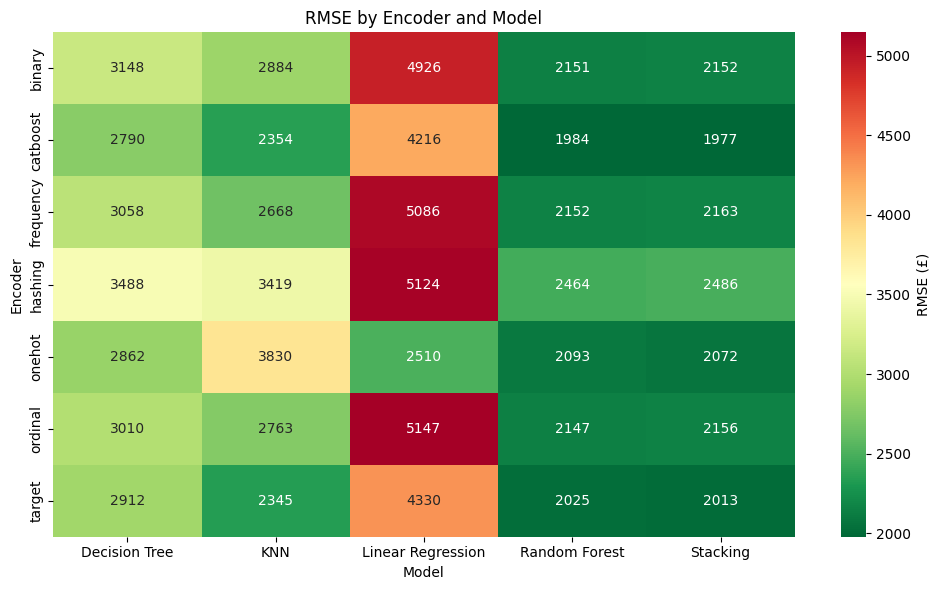

In [8]:
# This is likely the centerpiece visual of your results chapter:
# rows = encoder, columns = model, colour = RMSE (darker/lighter = better/worse)
plt.figure(figsize=(10, 6))
sns.heatmap(rmse_pivot, annot=True, fmt=".0f", cmap="RdYlGn_r", 
            cbar_kws={"label": "RMSE (£)"})
plt.title("RMSE by Encoder and Model")
plt.ylabel("Encoder")
plt.xlabel("Model")
plt.tight_layout()
plt.savefig("rmse_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

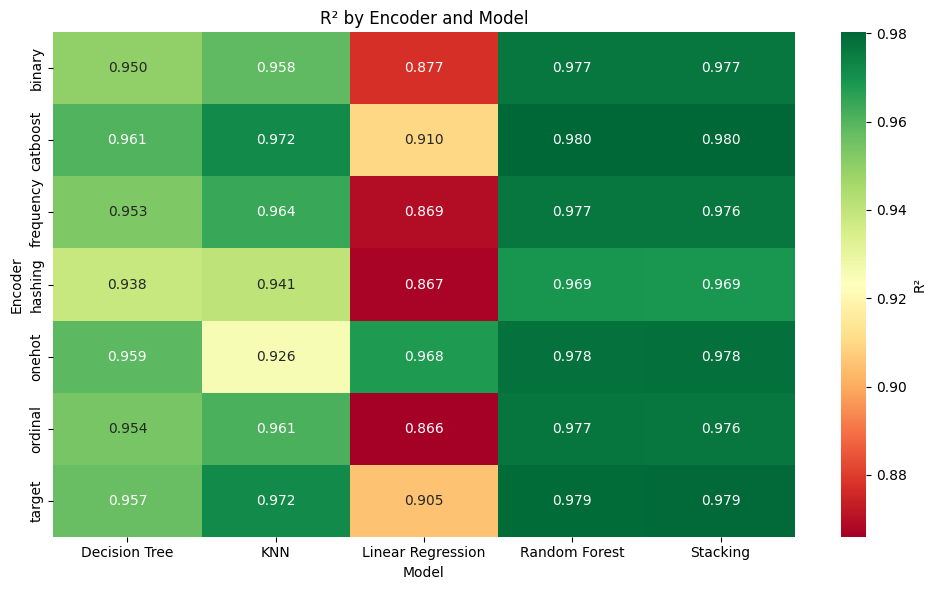

In [9]:
plt.figure(figsize=(10, 6))
sns.heatmap(r2_pivot, annot=True, fmt=".3f", cmap="RdYlGn",
            cbar_kws={"label": "R²"})
plt.title("R² by Encoder and Model")
plt.ylabel("Encoder")
plt.xlabel("Model")
plt.tight_layout()
plt.savefig("r2_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()